In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from drs4_parser.parser import event_stream, read_first_n, file_properties
from drs4_parser.parser import print_file_properties
from drs4_parser.events_filter.coincidence import file_coincidence_parser, event_coincidence_filter
from drs4_parser.time_analysis import cfd_linear, cfd_analog_time
from drs4_parser.pals import good_event, read_lifetime

from drs4_parser.energy_analysis.baseline import baseline_estimation
from drs4_parser.energy_analysis.pulse_height import pulse_height_3pts_parabolic, pulse_height_robust

In [2]:
# --------- CONFIG ---------
bin_file = "F:/Data/lifetime/drs4_bin.dat"
max_events = 10000
channels = file_properties(bin_file).channels[1:]
BINS_IN_WAVEFORM = 1024
# --------------------------


estimate energy treshold 

In [3]:
da = read_first_n(bin_file, max_events)

In [20]:
ch1_t, ch1_v = da['time'].sel(channel=[channels[0]]).values[0], da['voltage'].sel(channel=[channels[0]]).values[0]
ch2_t, ch2_v = da['time'].sel(channel=[channels[1]]).values[0], da['voltage'].sel(channel=[channels[1]]).values[0]

ch1_height = -pulse_height_robust(ch1_t, ch1_v)
ch2_height = -pulse_height_robust(ch2_t, ch2_v)

ch1_count, ch1_bins = np.histogram(ch1_height[np.isfinite(ch1_height)], bins=1024)
ch2_count, ch2_bins = np.histogram(ch2_height[np.isfinite(ch2_height)], bins=1024)

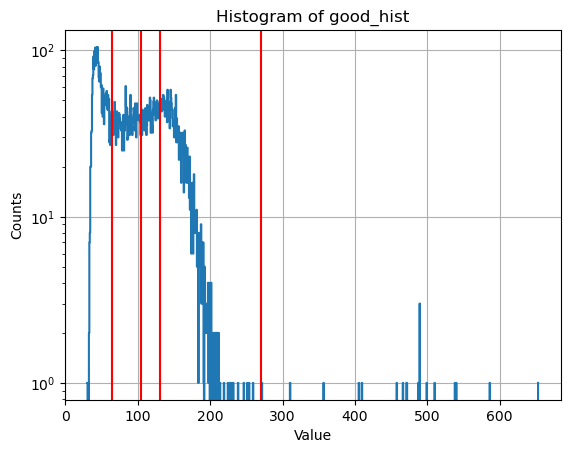

In [40]:
plt.step(ch1_bins[:-1], ch1_count, where='post')  # 'post' aligns steps correctly

plt.xlabel("Value")
plt.ylabel("Counts")
plt.title("Histogram of good_hist")
#plt.yscale('log')
#plt.xlim([4000,12000])
plt.grid()

ch1_511_lb = 65
ch1_511_ub = 105

ch1_1274_lb = 130
ch1_1274_ub = 270

plt.axvline(x=ch1_511_lb, color='red')
plt.axvline(x=ch1_511_ub, color='red')

plt.axvline(x=ch1_1274_lb, color='red')
plt.axvline(x=ch1_1274_ub, color='red') 
plt.yscale('log')

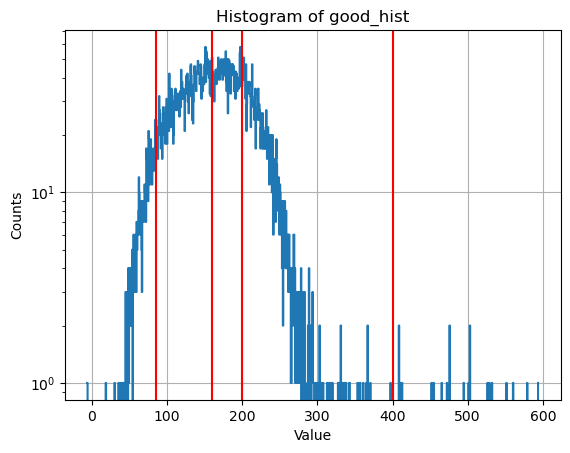

In [34]:
plt.step(ch2_bins[:-1], ch2_count, where='post')  # 'post' aligns steps correctly
plt.xlabel("Value")
plt.ylabel("Counts")
plt.title("Histogram of good_hist")
plt.yscale('log')
#plt.xlim([4000,12000])
plt.grid()

ch2_511_lb = 85
ch2_511_ub = 160


ch2_1274_lb = 200
ch2_1274_ub = 400

plt.axvline(x=ch2_511_lb, color='red')
plt.axvline(x=ch2_511_ub, color='red')

plt.axvline(x=ch2_1274_lb, color='red')
plt.axvline(x=ch2_1274_ub, color='red')

# read the times

In [23]:
lifetime = read_lifetime(bin_file,
                         channels=channels,
                         cfd_method="linear",
                         thresholds=(-65.0, -85.0),
                         cfd_fraction = 0.3, cfd_delay=1.4)

In [24]:
lifetime['event']

<xarray.DataArray 'event' (event: 6520)>
array([   0,    1,    2, ..., 6517, 6518, 6519])
Coordinates:
  * event    (event) int32 0 1 2 3 4 5 6 ... 6513 6514 6515 6516 6517 6518 6519

In [41]:
e1 = lifetime["energy_1"].values
e2 = lifetime["energy_2"].values
t1 = lifetime["time_1"].values
t2 = lifetime["time_2"].values

lb1_1274, ub1_1274 = -ch1_1274_lb, -ch1_1274_ub
lb1_511,  ub1_511  = -ch1_511_lb, -ch1_511_ub
lb2_1274, ub2_1274 = -ch2_1274_lb, -ch2_1274_ub
lb2_511,  ub2_511  = -ch2_511_lb, -ch2_511_ub

mask_1_2 = (
    (e1 < lb1_1274) & (e1 > ub1_1274) &
    (e2 < lb2_511)  & (e2 > ub2_511)
)

mask_2_1 = (
    (e2 < lb2_1274) & (e2 > ub2_1274) &
    (e1 < lb1_511)  & (e1 > ub1_511)
)

# one see first 1274
time_diff_1_2 = (t2 - t1)[mask_1_2]
# two see first 1274
time_diff_2_1 = (t2-t1)[mask_2_1]


In [43]:
len(time_diff_1_2)

1138

In [44]:
bins = np.arange(-7.5, 7.5, 10/1000)

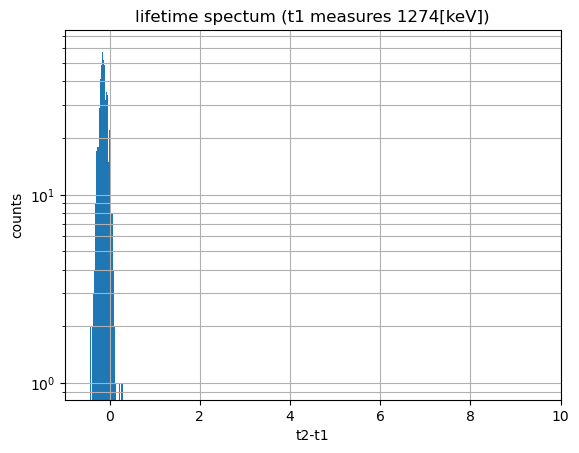

In [45]:
_ =plt.hist(time_diff_1_2, bins=bins)

plt.xlim([-1,10])
plt.yscale('log')
plt.title('lifetime spectum (t1 measures 1274[keV])')
plt.xlabel('t2-t1')
plt.ylabel('counts')
plt.grid(which='both')

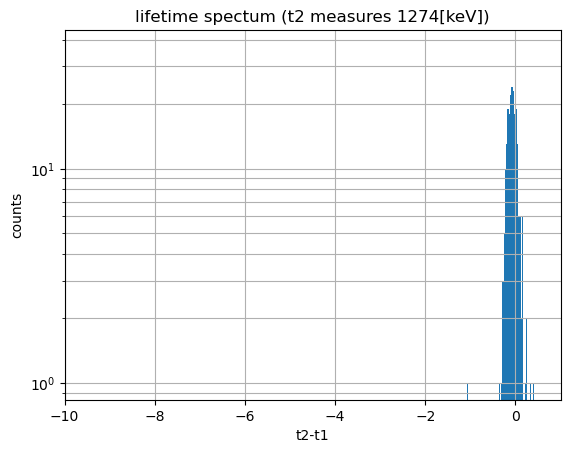

In [46]:
_ =plt.hist(time_diff_2_1, bins=bins)
plt.xlim([-10,1])
plt.yscale('log')
plt.title('lifetime spectum (t2 measures 1274[keV])')
plt.xlabel('t2-t1')
plt.ylabel('counts')
plt.grid(which='both')

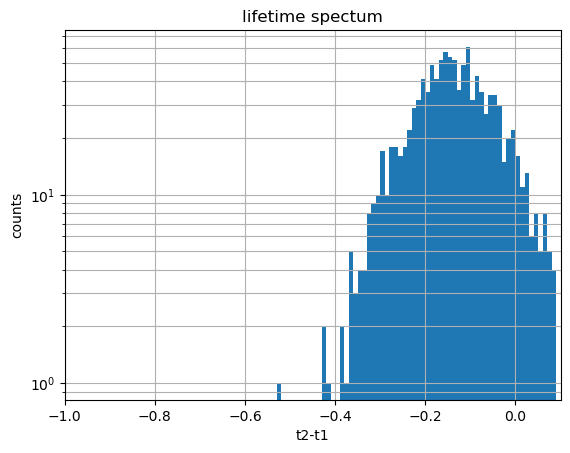

In [47]:
_ =plt.hist(time_diff_1_2, bins=bins)
plt.xlim([-1,0.1])
plt.yscale('log')
plt.title('lifetime spectum')
plt.xlabel('t2-t1')
plt.ylabel('counts')
plt.grid(which='both')